# Spline

**Fits and compares linear and natural cubic spline specifications of the treatment-effect heterogeneity model for mCRC cohort. Both models regress 2-year RMST pseudo-observations on treatment, calibrated 6-month survival probability, and their interaction using overlap weighting. The spline model (natural cubic spline, df=3) relaxes the linearity assumption of the primary analysis, allowing the treatment-effect function TE(r) to vary flexibly across the baseline risk continuum. Intended as a sensitivity analysis to the primary heterogeneity results.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
from statsmodels.formula.api import wls
import statsmodels.formula.api as smf
from patsy import dmatrix
import matplotlib.pyplot as plt

from iptw_survival import OverlapWeightSurvivalEstimator

from utils.treatment_effects import calculate_treatment_effect_curve_rmst

## Import data 

### Import calibrated survival probabilities 

In [2]:
surv_pred_df = pd.read_csv('../outputs/gb_6m_survival_predictions_calibrated.csv')

In [3]:
surv_pred_df.head(3)

,PatientID,psurv_180_calibrated
0,F12B04C749133,0.690401
1,FFFB7D51F655C,0.840842
2,F6E393E2A3FBA,1.000000


In [4]:
surv_pred_df.shape

(1074, 2)

### Import treatment assignment

In [5]:
treatment_df = pd.read_csv('../outputs/pembro_chemo_index.csv')

In [6]:
treatment_df.shape

(26405, 3)

In [7]:
treatment_df.head(3)

,PatientID,LineName,StartDate
0,FFFB7D51F655C,pembro,2023-10-04
1,FB62DC3D3C20F,pembro,2025-06-05
2,F15B1F9F90957,pembro,2018-07-31


### Import features

In [8]:
dtype_map = pd.read_csv('../outputs/pembro_chemo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/pembro_chemo_features_df.csv', dtype = dtype_map)

In [9]:
features_df.shape

(1208, 170)

### Import RMST pseudo-observations

In [10]:
pseudo_obs_df = pd.read_csv('../outputs/pseudo_obs_rmst.csv')

In [11]:
pseudo_obs_df.shape

(1074, 3)

In [12]:
pseudo_obs_df.head(3)

,PatientID,rmst_pseudo_1y,rmst_pseudo_2y
0,F12B04C749133,366.950404,740.005907
1,FFFB7D51F655C,366.950404,739.813368
2,F6E393E2A3FBA,366.950404,740.005907


### Merge dataframes

In [13]:
df = pd.merge(features_df, surv_pred_df, on = 'PatientID', how = 'left')

In [14]:
df.shape

(1208, 171)

In [15]:
df = pd.merge(df, pseudo_obs_df, on = 'PatientID', how = 'left')

In [16]:
df.shape

(1208, 173)

In [17]:
df = pd.merge(df, treatment_df, on = 'PatientID', how = 'left')

In [18]:
df.shape

(1208, 175)

In [19]:
df = df.query('met_diagnosis_year <= 2023')

In [20]:
df.shape

(1074, 175)

## Calculating overlap weights

In [21]:
df['treatment'] = np.where(df['LineName'] == 'pembro', 1, 0)

In [22]:
df.treatment.value_counts()

treatment
0    685
1    389
Name: count, dtype: int64

In [23]:
estimator = OverlapWeightSurvivalEstimator(normalize = None)

In [24]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['CrcSite'],
              cont_var = ['days_diagnosis_to_met', 'GroupStage_mod', 'ecog_index', 'ses_mod', 'age', 'percent_change_weight', 'hemoglobin', 'albumin', 'alp', 'cea', 'van_walraven_score'],
              binary_var = ['sex_male', 'ecog_index_na', 'ses_mod_na', 'medicaid', 'days_to_treatment_before_30d'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              use_missing_flags = False)

In [25]:
overlap_df = estimator.transform()

In [26]:
ps_fig = estimator.propensity_score_plot(bins = 30)

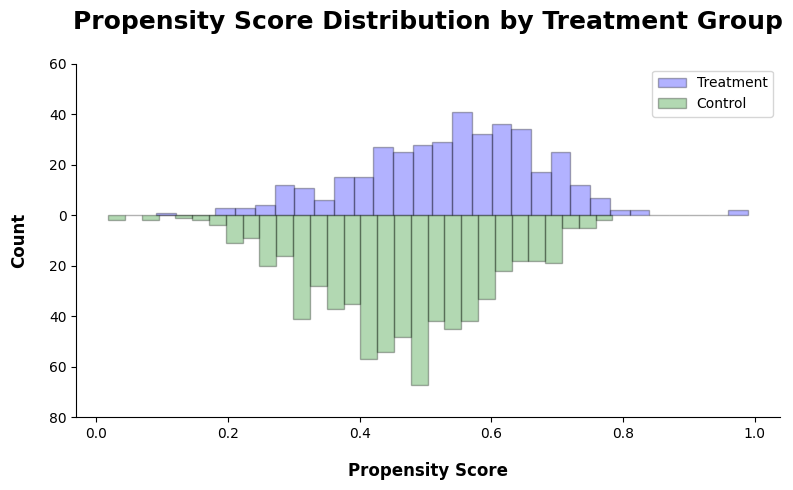

In [27]:
ps_fig

## WLS model

In [28]:
# Create grid of psurv_180 values (5th to 95th percentile)
psurv_grid = np.linspace(
    overlap_df['psurv_180_calibrated'].quantile(0.05),
    overlap_df['psurv_180_calibrated'].quantile(0.95),
    200
)

In [29]:
formula_2y = 'rmst_pseudo_2y ~ treatment * psurv_180_calibrated'

model_2y = wls(
    formula = formula_2y,
    data = overlap_df,
    weights = overlap_df['overlap_weight']
).fit(cov_type = 'HC3')

print(model_2y.summary())

                            WLS Regression Results                            
Dep. Variable:         rmst_pseudo_2y   R-squared:                       0.237
Model:                            WLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     131.6
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           1.45e-72
Time:                        05:53:53   Log-Likelihood:                -7395.1
No. Observations:                1074   AIC:                         1.480e+04
Df Residuals:                    1070   BIC:                         1.482e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [30]:
# Create spline basis
spline_basis = dmatrix(
    "cr(psurv_180_calibrated, df=3) - 1", 
    {"psurv_180_calibrated": df['psurv_180_calibrated']}
)

# Add to dataframe
df_spline = overlap_df.copy()
df_spline['spline_0'] = spline_basis[:, 0]
df_spline['spline_1'] = spline_basis[:, 1]
df_spline['spline_2'] = spline_basis[:, 2]

# Fit spline model with explicit terms
model_spline = smf.wls(
    'rmst_pseudo_2y ~ treatment + spline_0 + spline_1 + spline_2 + '
    'treatment:spline_0 + treatment:spline_1 + treatment:spline_2',
    data=df_spline,
    weights=df_spline['overlap_weight']
).fit(cov_type = 'HC3')

In [31]:
# Calculate treatment effects for SPLINE model
# Need to create spline basis for prediction grid
spline_basis_grid = dmatrix(
    "cr(psurv_180_calibrated, df=3) - 1",
    {"psurv_180_calibrated": psurv_grid}
)

# Create prediction dataframes for treatment effect calculation
pred_grid_0 = pd.DataFrame({
    'treatment': 0,
    'spline_0': spline_basis_grid[:, 0],
    'spline_1': spline_basis_grid[:, 1],
    'spline_2': spline_basis_grid[:, 2]
})

pred_grid_1 = pd.DataFrame({
    'treatment': 1,
    'spline_0': spline_basis_grid[:, 0],
    'spline_1': spline_basis_grid[:, 1],
    'spline_2': spline_basis_grid[:, 2]
})

# Get predictions with confidence intervals
pred_0 = model_spline.get_prediction(pred_grid_0)
pred_1 = model_spline.get_prediction(pred_grid_1)

# Calculate treatment effect (difference)
effect_2y_spline = pd.DataFrame({
    'baseline': psurv_grid,
    'treatment_effect': pred_1.predicted_mean - pred_0.predicted_mean,
    'ci_lower': pred_1.conf_int()[:, 0] - pred_0.conf_int()[:, 1],
    'ci_upper': pred_1.conf_int()[:, 1] - pred_0.conf_int()[:, 0]
})

In [32]:
# Calculate linear treatment effects using the utils function
effect_2y_df = calculate_treatment_effect_curve_rmst(
    model = model_2y,
    baseline_var = 'psurv_180_calibrated',
    baseline_values = psurv_grid
)

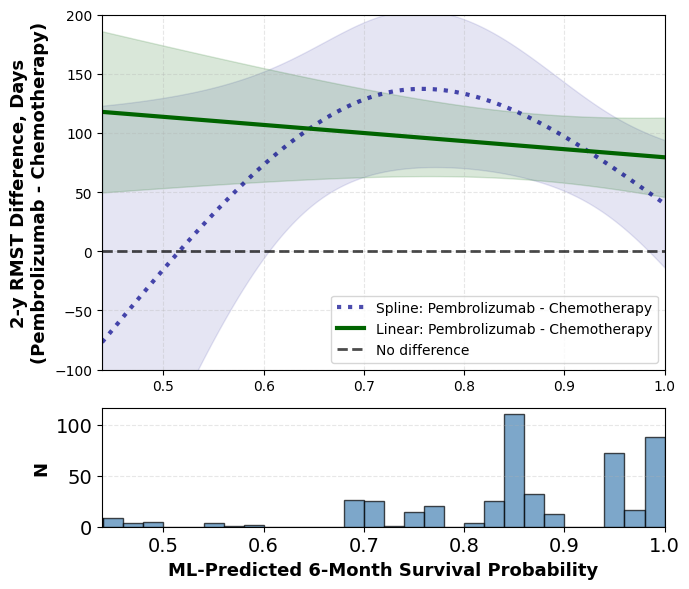

In [34]:
# Plot treatment effect - comparing both models
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), gridspec_kw={'height_ratios': [3, 1]})

# Plot spline model
ax1.plot(effect_2y_spline['baseline'], effect_2y_spline['treatment_effect'], 
         linewidth=3, color='darkblue', label='Spline: Pembrolizumab - Chemotherapy',
         linestyle=':', alpha=0.7)

ax1.fill_between(effect_2y_spline['baseline'], 
                 effect_2y_spline['ci_lower'], 
                 effect_2y_spline['ci_upper'], 
                 alpha=0.1, color='darkblue')

# Plot linear model 
ax1.plot(effect_2y_df['baseline'], effect_2y_df['treatment_effect'], 
         linewidth = 3, color = 'darkgreen', label = 'Linear: Pembrolizumab - Chemotherapy')

ax1.fill_between(effect_2y_df['baseline'], effect_2y_df['ci_lower'], effect_2y_df['ci_upper'], 
                 alpha = 0.15, color = 'darkgreen')

ax1.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7, label='No difference')

ax1.set_ylabel('2-y RMST Difference, Days\n(Pembrolizumab - Chemotherapy)', 
               fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='lower right')
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_xlim([psurv_grid.min(), psurv_grid.max()])
ax1.set_ylim(-100, 200)

# Bottom panel - histogram
ax2.hist(overlap_df['psurv_180_calibrated'], 
         bins=50,
         weights=overlap_df['overlap_weight'],
         alpha=0.7, 
         edgecolor='black', 
         color='steelblue')

ax2.set_xlabel('ML-Predicted 6-Month Survival Probability', fontsize = 13, fontweight = 'bold')
ax2.set_ylabel('N', fontsize = 13, fontweight = 'bold')
ax2.set_xlim([psurv_grid.min(), psurv_grid.max()])
ax2.grid(alpha = 0.3, linestyle = '--', axis = 'y')
ax2.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('../outputs/spline.pdf', format = 'pdf', bbox_inches = 'tight')
plt.show()